In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pygris import block_groups       # ⬅️ THIS
import contextily as cx               # if you're using the basemap
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import os

# ---------------------------------------------------------
# 0. Detect folder where THIS script is located
# ---------------------------------------------------------
script_dir = os.getcwd()
out_dir = script_dir
print("Saving all outputs to:", out_dir)

# ---------------------------------------------------------
# 1. File paths (input files can be anywhere)
# ---------------------------------------------------------
orig_file  = "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/data_mesozone_emprankings_lehd.csv"
calib_file = "/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/inputs_Boston/data_mesozone_emprankings.csv"

orig = pd.read_csv(orig_file)
cal  = pd.read_csv(calib_file)

orig = orig[orig['COUNTY']>0]
cal = cal[cal['COUNTY']>0]

print("Original shape:", orig.shape)
print("Calibrated shape:", cal.shape)

print(orig.keys())
print(cal.keys())


Saving all outputs to: /Users/cpoliziani/Documents/repo/SynthFirm/scenario_analysis/emp_rankings
Original shape: (6457, 22)
Calibrated shape: (6457, 22)
Index(['MESOZONE', 'rank11', 'rank21', 'rank22', 'rank23', 'rank3133',
       'rank42', 'rank4445', 'rank4849', 'rank51', 'rank52', 'rank53',
       'rank54', 'rank55', 'rank56', 'rank61', 'rank62', 'rank71', 'rank72',
       'rank81', 'rank92', 'COUNTY'],
      dtype='object')
Index(['MESOZONE', 'COUNTY', 'rank11', 'rank21', 'rank22', 'rank23',
       'rank3133', 'rank42', 'rank4445', 'rank4849', 'rank51', 'rank52',
       'rank53', 'rank54', 'rank55', 'rank56', 'rank61', 'rank62', 'rank71',
       'rank72', 'rank81', 'rank92'],
      dtype='object')


In [2]:
# ---------------------------------------------------------
# 2. Align common NAICS rank columns
# ---------------------------------------------------------
rank_cols_orig = [c for c in orig.columns if c.startswith("rank")]
rank_cols_cal  = [c for c in cal.columns  if c.startswith("rank")]
common_rank_cols = sorted(set(rank_cols_orig).intersection(rank_cols_cal))
print("Common NAICS rank columns:", len(common_rank_cols))

meta_cols_orig = ["MESOZONE"] + [c for c in ["COUNTY"] if c in orig.columns]
meta_cols_cal  = ["MESOZONE"] + [c for c in ["COUNTY"] if c in cal.columns]

orig_sub = orig[meta_cols_orig + common_rank_cols].copy()
cal_sub  = cal[meta_cols_cal  + common_rank_cols].copy()



Common NAICS rank columns: 20


orig_sub["orig_total"] 4518552.0
cal_sub["orig_total"] 7949136.0

=== ABSOLUTE change per MESOZONE ===
count     6457.000000
mean       531.296887
std       1489.952644
min     -10382.000000
25%         32.000000
50%        214.000000
75%        631.000000
max      37758.000000
Name: abs_diff, dtype: float64


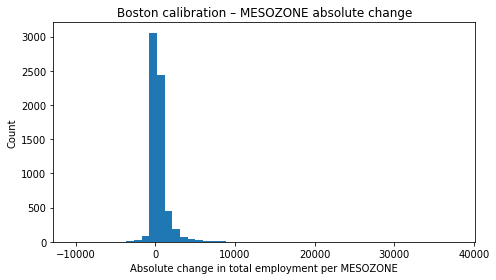

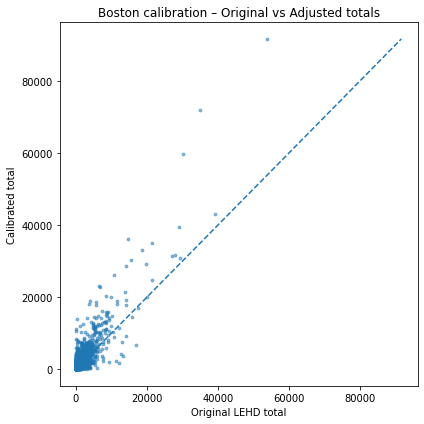

In [3]:
# ---------------------------------------------------------
# 3. MESOZONE TOTALS (absolute differences)
# ---------------------------------------------------------
orig_sub["orig_total"] = orig_sub[common_rank_cols].sum(axis=1)
cal_sub["adj_total"]   = cal_sub[common_rank_cols].sum(axis=1)

print('orig_sub["orig_total"]',orig_sub[common_rank_cols].sum().sum())
print('cal_sub["orig_total"]',cal_sub[common_rank_cols].sum().sum())

orig_totals = orig_sub[["MESOZONE", "orig_total"]].groupby("MESOZONE", as_index=False).sum()
adj_totals  = cal_sub[["MESOZONE", "adj_total"]].groupby("MESOZONE", as_index=False).sum()

diff_df = orig_totals.merge(adj_totals, on="MESOZONE", how="outer").fillna(0)
diff_df["abs_diff"] = diff_df["adj_total"] - diff_df["orig_total"]

print("\n=== ABSOLUTE change per MESOZONE ===")
print(diff_df["abs_diff"].describe())

diff_df.to_csv(os.path.join(out_dir, "boston_abs_change_mesozone.csv"), index=False)

# Histogram
plt.figure(figsize=(7, 4))
plt.hist(diff_df["abs_diff"], bins=50)
plt.xlabel("Absolute change in total employment per MESOZONE")
plt.ylabel("Count")
plt.title("Boston calibration – MESOZONE absolute change")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "boston_abs_change_hist_mesozone.png"), dpi=200)
plt.show()

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(diff_df["orig_total"], diff_df["adj_total"], s=8, alpha=0.5)
max_val = max(diff_df["orig_total"].max(), diff_df["adj_total"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.xlabel("Original LEHD total")
plt.ylabel("Calibrated total")
plt.title("Boston calibration – Original vs Adjusted totals")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "boston_orig_vs_adj_scatter.png"), dpi=200)
plt.show()


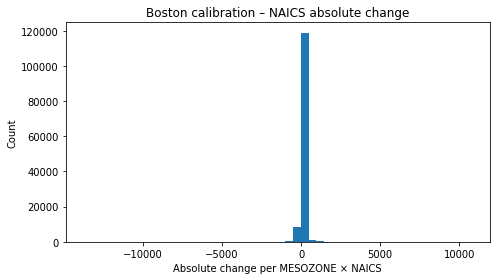

In [4]:

# ---------------------------------------------------------
# 4. MESOZONE × NAICS DIFFERENCES
# ---------------------------------------------------------
def to_long(df, value_name):
    return df.melt(
        id_vars=[c for c in df.columns if not c.startswith("rank")],
        value_vars=common_rank_cols,
        var_name="NAICS",
        value_name=value_name
    )

orig_long = to_long(orig_sub, "orig_emp")
cal_long  = to_long(cal_sub,  "adj_emp")

long_df = (
    orig_long[["MESOZONE", "NAICS", "orig_emp"] + [c for c in ["COUNTY"] if "COUNTY" in orig_long.columns]]
    .merge(cal_long[["MESOZONE", "NAICS", "adj_emp"]], on=["MESOZONE", "NAICS"], how="outer")
    .fillna(0)
)

long_df["abs_diff"] = long_df["adj_emp"] - long_df["orig_emp"]
long_df.to_csv(os.path.join(out_dir, "boston_abs_change_naics.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.hist(long_df["abs_diff"], bins=50)
plt.xlabel("Absolute change per MESOZONE × NAICS")
plt.ylabel("Count")
plt.title("Boston calibration – NAICS absolute change")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "boston_abs_change_hist_naics.png"), dpi=200)
plt.show()



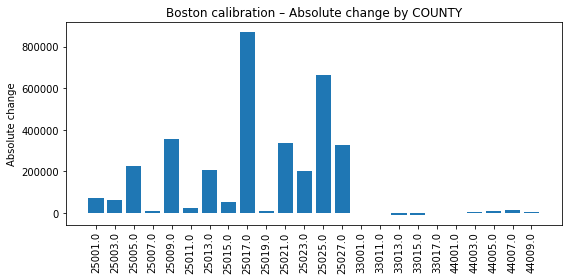

In [5]:
# ---------------------------------------------------------
# 5. COUNTY AGGREGATION (if COUNTY exists)
# ---------------------------------------------------------
if "COUNTY" in long_df.columns:
    county_df = long_df.groupby("COUNTY", as_index=False)[["orig_emp", "adj_emp"]].sum()
    county_df["abs_diff"] = county_df["adj_emp"] - county_df["orig_emp"]
    county_df.to_csv(os.path.join(out_dir, "boston_abs_change_county.csv"), index=False)

    plt.figure(figsize=(8, 4))
    plt.bar(county_df["COUNTY"].astype(str), county_df["abs_diff"])
    plt.xticks(rotation=90)
    plt.ylabel("Absolute change")
    plt.title("Boston calibration – Absolute change by COUNTY")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "boston_abs_change_by_county.png"), dpi=200)
    plt.show()
else:
    print("No COUNTY column detected → skipping county-level plots.")


Using FIPS code '25' for input 'MA'
Using FIPS code '44' for input 'RI'
Using FIPS code '33' for input 'NH'
Using FIPS code '09' for input 'CT'
--------------------------------------------------
GEOIDs in diff_df (MESOZONE): 6457
GEOIDs in MA+RI+NH+CT block groups: 9307
Matched GEOIDs in final GDF: 6457
Block groups with missing geometry: 0

Example missing rows:
Empty DataFrame
Columns: [GEOID, orig_total, adj_total]
Index: []
--------------------------------------------------


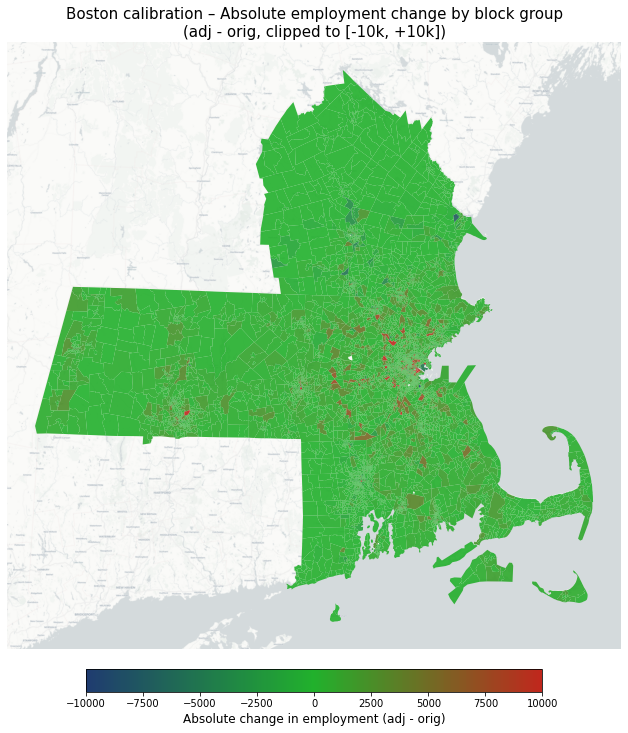

Saved map to: /Users/cpoliziani/Documents/repo/SynthFirm/scenario_analysis/emp_rankings/boston_abs_change_map_-10k_+10k_blue-green-red.png
Range of abs_diff_per_km2: count      6457.000000
mean        716.777483
std        4403.921395
min     -108176.101538
25%           6.167750
50%          89.986550
75%         444.061490
max      177526.611862
Name: abs_diff_per_km2, dtype: float64


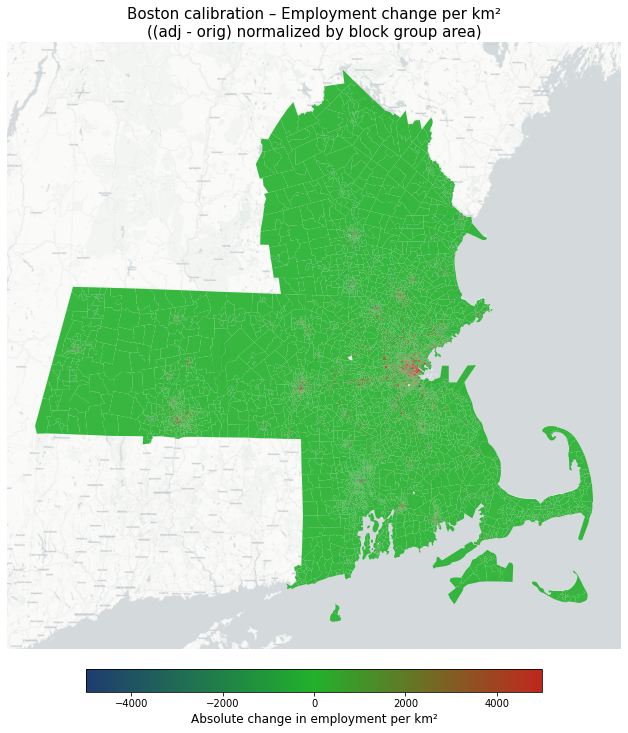

Saved map to: /Users/cpoliziani/Documents/repo/SynthFirm/scenario_analysis/emp_rankings/boston_abs_change_per_km2_map.png

All files saved to: /Users/cpoliziani/Documents/repo/SynthFirm/scenario_analysis/emp_rankings


In [6]:

# ---------------------------------------------------------
# 6. MAP OF ABSOLUTE CHANGES (MESOZONE)
# ---------------------------------------------------------


# ---------------------------------------------
# 1. Prepara GEOID e geometrie
# ---------------------------------------------
diff_df["GEOID"] = diff_df["MESOZONE"].astype(str).str.zfill(12)

ma_bg = block_groups(state="MA", year=2018, cache=True)
ri_bg = block_groups(state="RI", year=2018, cache=True)
nh_bg = block_groups(state="NH", year=2018, cache=True)
ct_bg = block_groups(state="CT", year=2018, cache=True)
bg = pd.concat([ma_bg, ri_bg,nh_bg,ct_bg ], ignore_index=True)[["GEOID", "geometry"]]

gdf = bg.merge(diff_df, on="GEOID", how="right").to_crs(3857)

# Count GEOIDs in each dataset
n_diff = diff_df["GEOID"].nunique()
n_bg   = bg["GEOID"].nunique()

# How many matched?
matched = gdf["GEOID"].notna().sum()
missing_geo = gdf["geometry"].isna().sum()

print("--------------------------------------------------")
print("GEOIDs in diff_df (MESOZONE):", n_diff)
print("GEOIDs in MA+RI+NH+CT block groups:", n_bg)
print("Matched GEOIDs in final GDF:", matched)
print("Block groups with missing geometry:", missing_geo)

# Show first missing ones if any
missing_rows = gdf[gdf["geometry"].isna()][["GEOID", "orig_total", "adj_total"]].head()
print("\nExample missing rows:")
print(missing_rows)
print("--------------------------------------------------")

# ---------------------------------------------
# 2. Scala lineare fissa [-10000, 0, +10000]
# ---------------------------------------------
vmin, vcenter, vmax = -10000, 0, 10000
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# blu -> verde -> rosso
cmap = LinearSegmentedColormap.from_list(
    "blue_green_red",
    [
        (0.0, "#1f3b70"),  # blu
        (0.5, "#21b12c"),  # verde (0)
        (1.0, "#c0271d"),  # rosso
    ],
    N=256,
)

# ---------------------------------------------
# 3. Plot mappa
# ---------------------------------------------
fig, ax = plt.subplots(figsize=(11, 12))

gdf.plot(
    column="abs_diff",        # signed change (adj - orig)
    cmap=cmap,
    norm=norm,
    ax=ax,
    alpha=0.9,
    edgecolor="none"
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,
    attribution=False,
    zoom=10
)

ax.set_axis_off()
ax.set_title(
    "Boston calibration – Absolute employment change by block group\n(adj - orig, clipped to [-10k, +10k])",
    fontsize=15
)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.03
)
cbar.set_label("Absolute change in employment (adj - orig)", fontsize=12)

map_path = os.path.join(out_dir, "boston_abs_change_map_-10k_+10k_blue-green-red.png")
plt.savefig(map_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved map to:", map_path)

# ---------------------------------------------------------
# Mappa employment change per km² (abs_diff normalized by area)
# ---------------------------------------------------------

# 1. Compute area in km² (CRS 3857 = meters)
gdf["area_km2"] = gdf.geometry.area / 1e6

# Avoid division by zero
gdf["area_km2"] = gdf["area_km2"].replace(0, np.nan)

# 2. Compute normalized change
gdf["abs_diff_per_km2"] = gdf["abs_diff"] / gdf["area_km2"]

print("Range of abs_diff_per_km2:", gdf["abs_diff_per_km2"].describe())

# 3. Define scale (adjust if needed)
vmin, vcenter, vmax = -5000, 0, 5000
norm_km2 = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# Reuse same blue-green-red colormap
cmap_km2 = cmap  # already defined above

# 4. Plot map
fig, ax = plt.subplots(figsize=(11, 12))

gdf.plot(
    column="abs_diff_per_km2",
    cmap=cmap_km2,
    norm=norm_km2,
    ax=ax,
    alpha=0.9,
    edgecolor="none"
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,
    attribution=False,
    zoom=10
)

ax.set_axis_off()
ax.set_title(
    "Boston calibration – Employment change per km²\n((adj - orig) normalized by block group area)",
    fontsize=15
)

# Scale legend
sm = plt.cm.ScalarMappable(norm=norm_km2, cmap=cmap_km2)
sm._A = []
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.03
)
cbar.set_label("Absolute change in employment per km²", fontsize=12)

map_path_km2 = os.path.join(out_dir, "boston_abs_change_per_km2_map.png")
plt.savefig(map_path_km2, dpi=300, bbox_inches="tight")
plt.show()
print("Saved map to:", map_path_km2)


print("\nAll files saved to:", out_dir)